In [1]:
import sys

import diffusers
import matplotlib.pyplot as plt
import torch
import transformers
from IPython.display import display
from PIL import Image
from torchinfo import summary
from tqdm.notebook import tqdm

In [2]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.5.1+cu118
11.8
Tesla P100-PCIE-16GB


In [3]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("diffusers version:", diffusers.__version__)
print("transformers version:", transformers.__version__)
print("torch version:", torch.__version__)
print("PIL version:", Image.__version__)

Platform: linux
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
---
diffusers version: 0.36.0
transformers version: 5.0.0
torch version: 2.5.1+cu118
PIL version: 11.3.0


In [4]:
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_device_capability(0))

Tesla P100-PCIE-16GB
11.8
(6, 0)


In [5]:
print(torch.__version__)

2.5.1+cu118


In [6]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.5.1+cu118
11.8
Tesla P100-PCIE-16GB


In [7]:
# check for availability of gpu
if torch.cuda.is_available():
    device = 'cuda'
    dtype = torch.float16
else:
    device = 'cpu'
    dtype = torch.float32

In [8]:
device

'cuda'

In [9]:
# introducing a tokenizer that converts text(the text we want to display as an image) to numbers

tokenizer = transformers.CLIPTokenizer.from_pretrained(
    'compVis/stable-diffusion-v1-4', subfolder='tokenizer',
    torch_dtype= dtype,
    local_files_only=True
)

In [10]:
print(tokenizer)

CLIPTokenizer(name_or_path='compVis/stable-diffusion-v1-4', vocab_size=2, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	0: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [11]:
# let's test the tokenizer
text = 'Hello, world!'
result = tokenizer(text)

In [12]:
print(type(result))
print(result)

<class 'transformers.tokenization_utils_base.BatchEncoding'>
{'input_ids': [0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [13]:
# accessing the elements of the containers
print(result['input_ids'])

# Or

print(result.input_ids)

[0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [14]:
len(result.input_ids)

14

In [15]:
# decoding a token to get back the word
[print(tokenizer.decode(token)) for token in result.input_ids]

<|startoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>
<|endoftext|>


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

### Tokenizing the Prompt

In [16]:
# let's get a prompt for our first image

prompt = 'A red goat flies through a forest'

In [18]:
# let's tweak the tokenizer to genrate a fixed number of output tokens 
# and also return a pytorch tensor not a python list

text_tokens = tokenizer(
    prompt,
    padding = 'max_length',     # max number of available tokens
    truncation = True,
    max_length = 77,
    return_tensors = 'pt'
)

In [21]:
print(text_tokens.input_ids)
print(text_tokens.input_ids.shape)

tensor([[0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2]])
torch.Size([1, 77])


In [22]:
text_tokens.input_ids.shape[1]

77

In [23]:
# Stable Diffusion works with a model *conditioned* on our text.  
# For this to work, we need an *unconditioned* result to compare to.  
# For this, we'll use the empty string.

uncond_tokens = tokenizer(
    "",
    padding = "max_length",
    truncation = True,
    max_length = text_tokens.input_ids.shape[1],
    return_tensors = 'pt'
)

In [24]:
print(uncond_tokens.input_ids)
print(uncond_tokens.input_ids.shape)

tensor([[0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2]])
torch.Size([1, 77])


In [25]:
checker = [tokenizer.decode(token) for token in uncond_tokens.input_ids]
print(checker)

['<|startoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoft

In [26]:
checkert = [tokenizer.decode(token) for token in text_tokens.input_ids]
print(checkert)

['<|startoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoft

### Generating Embeddings

In [27]:
# Now, time to convert the tokens to text embeddings
embedder = transformers.CLIPTextModel.from_pretrained(
    'CompVis/stable-diffusion-v1-4', subfolder = 'text_encoder',
    torch_dtype = dtype,
)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: CompVis/stable-diffusion-v1-4
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
# supposed to do this on the gpu but ...
embedder.to(device)

CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e

In [29]:
summary(embedder)

Layer (type:depth-idx)                                       Param #
CLIPTextModel                                                --
├─CLIPTextTransformer: 1-1                                   --
│    └─CLIPTextEmbeddings: 2-1                               --
│    │    └─Embedding: 3-1                                   37,945,344
│    │    └─Embedding: 3-2                                   59,136
│    └─CLIPEncoder: 2-2                                      --
│    │    └─ModuleList: 3-3                                  85,054,464
│    └─LayerNorm: 2-3                                        1,536
Total params: 123,060,480
Trainable params: 123,060,480
Non-trainable params: 0

In [30]:
# call the embedders with the token ids to generate the text embeddings
with torch.no_grad():
    text_embedding = embedder(text_tokens.input_ids.to(device))

In [31]:
print(type(text_embedding))

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>


In [32]:
# we are interested in the last hidden state attribute
text_embedding.keys()

odict_keys(['last_hidden_state', 'pooler_output'])

In [33]:
print(type(text_embedding.last_hidden_state))
print(text_embedding.last_hidden_state.shape)

<class 'torch.Tensor'>
torch.Size([1, 77, 768])


#### The test tokens have been converted to a 768 long vector

In [34]:
# embeddings for the uncond tokens
with torch.no_grad():
    uncond_embedding = embedder(uncond_tokens.input_ids.to(device))

In [35]:
print(type(uncond_embedding.last_hidden_state))
print(uncond_embedding.last_hidden_state.shape)

<class 'torch.Tensor'>
torch.Size([1, 77, 768])


In [36]:
# concatenating the embeddings
all_embeddings = torch.cat([uncond_embedding.last_hidden_state, text_embedding.last_hidden_state])

### Generate Random Latent Vectors

In [37]:
# we generate images from latent vectors (gonna use VAE)
vae = diffusers.AutoencoderKL.from_pretrained(
    'CompVis/stable-diffusion-v1-4', subfolder = 'vae',
    torch_dtype = dtype,
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [38]:
from diffusers import AutoencoderKL

try:
    vae = AutoencoderKL.from_pretrained(
        'CompVis/stable-diffusion-v1-4',
        subfolder = 'vae',
        torch_dtype = dtype
    )
    print('Download Successful')
except Exception as e:
    print(f"Download failed: {e}")

Download Successful


In [39]:
unet = diffusers.UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet",
    torch_dtype=torch.float16,
)

In [40]:
scheduler = diffusers.UniPCMultistepScheduler.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="scheduler",
)

In [41]:
from diffusers import UniPCMultistepScheduler

try:
    unet = UniPCMultistepScheduler.from_pretrained(
        'CompVis/stable-diffusion-v1-4', subfolder = 'scheduler',
    )
    print('Download Successful')
except Exception as e:
    print(f"Download Failed: {e}") 

Download Successful


In [42]:
# run the vae on gpu but my device is cpu tho
vae.to(device)

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [43]:
summary(vae)

Layer (type:depth-idx)                             Param #
AutoencoderKL                                      --
├─Encoder: 1-1                                     --
│    └─Conv2d: 2-1                                 3,584
│    └─ModuleList: 2-2                             --
│    │    └─DownEncoderBlock2D: 3-1                738,944
│    │    └─DownEncoderBlock2D: 3-2                2,690,304
│    │    └─DownEncoderBlock2D: 3-3                10,754,560
│    │    └─DownEncoderBlock2D: 3-4                9,443,328
│    └─UNetMidBlock2D: 2-3                         --
│    │    └─ModuleList: 3-5                        1,051,648
│    │    └─ModuleList: 3-6                        9,443,328
│    └─GroupNorm: 2-4                              1,024
│    └─SiLU: 2-5                                   --
│    └─Conv2d: 2-6                                 36,872
├─Decoder: 1-2                                     --
│    └─Conv2d: 2-7                                 18,944
│    └─ModuleList: 2-8

In [44]:
height = 512
width = 512
scale_factor = 8        # the encoder doenscales the width and height by the scale factor

In [45]:
n_channels = vae.config.latent_channels
print(n_channels)

# Latent vectors will be a a 4-D tensor(batch, channels, height, width)

4


In [46]:
# specifying the latent vector shape
latent_shape = (
    1,  # batch size
    n_channels, # latent channels
    height // scale_factor,
    width // scale_factor
)

In [47]:
random_latents = torch.randn(latent_shape, device=device, dtype=dtype)

In [48]:
print(random_latents.shape)

torch.Size([1, 4, 64, 64])


In [49]:
random_latents

tensor([[[[ 1.4893,  0.4380, -0.4045,  ..., -0.7222,  1.6426, -1.6318],
          [-0.7827, -0.4214,  0.7939,  ..., -0.3694, -0.5713,  0.4084],
          [ 0.3318, -0.2700, -0.2861,  ...,  0.5879,  0.0045,  0.7915],
          ...,
          [ 1.3242, -1.0322, -0.4685,  ..., -1.1641,  0.5938, -1.5889],
          [-0.3037,  0.6313,  1.5977,  ..., -0.4385,  0.2052, -0.7280],
          [ 0.9395,  0.7158, -0.4055,  ...,  1.0381, -1.5752,  0.8521]],

         [[ 1.6768,  0.6875, -0.5068,  ..., -0.6235, -0.2896, -0.0331],
          [ 1.1006, -0.7070,  1.2363,  ..., -0.6143,  0.7520,  0.2620],
          [ 1.5342, -0.0856, -1.0928,  ...,  0.2600,  1.0137, -0.9663],
          ...,
          [-0.5356, -0.1505,  0.7075,  ..., -1.4795,  0.3613,  1.6348],
          [ 0.8535,  0.1824,  1.0527,  ..., -0.5347,  1.3438,  1.9453],
          [ 1.3379,  1.6670,  0.7368,  ...,  0.2744, -0.8032, -0.7676]],

         [[-2.4883,  0.4119,  0.2791,  ...,  0.0959, -0.2759, -0.5063],
          [ 0.7568,  1.1729, -

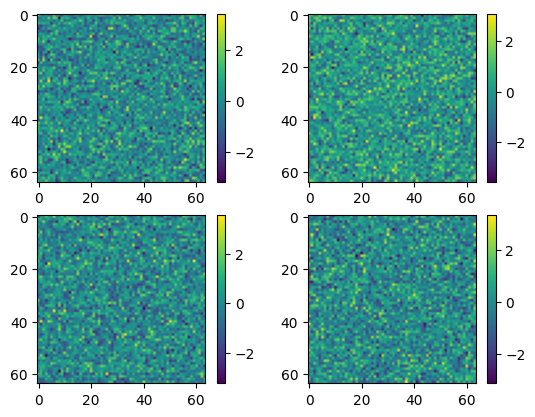

In [50]:
# since there are 4 channels we cant view the latent vector as an RGB image. Lets plot the latents
def plot_latents(latents):
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(latents[0, i].cpu().numpy())
        plt.colorbar()

plot_latents(random_latents)

#### Decoding the latent vectors


In [51]:
# using vae to decode
latents = random_latents

with torch.no_grad():
    scaling_factor = torch.tensor(vae.config.scaling_factor, device= device, dtype=dtype)
    decoded = vae.decode(latents / scaling_factor).sample

In [52]:
print('decoded_tensor_shape', decoded.shape)

decoded_tensor_shape torch.Size([1, 3, 512, 512])


In [53]:
# rearranging the shape to (height, width, channels) accepted by PIL
unscaled = decoded.permute(0, 2, 3, 1).cpu().numpy()
print('Shape_Unscaled:', unscaled.shape)

Shape_Unscaled: (1, 512, 512, 3)


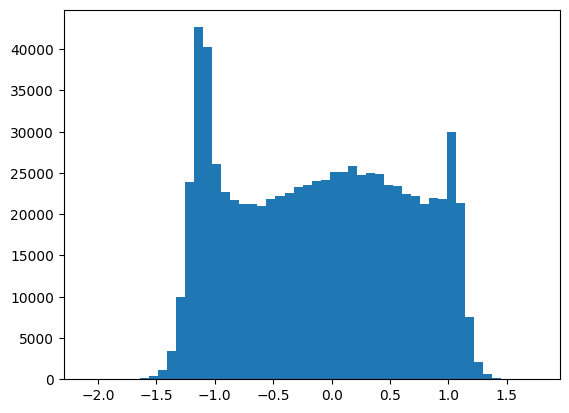

In [54]:
# histogram of the values in unscaled array
plt.hist(
    unscaled.flatten(),
    bins = 50
);

In [56]:
# it shows that most values are [-1, 1] which will be upscaled to [0,225] and clip the remaining values
scaled = ((unscaled + 1) * 255/2).clip(0, 255).round().astype('uint8')

# also converted the images to the datatype to the unsigned 8-bit integer type commonly used for images.


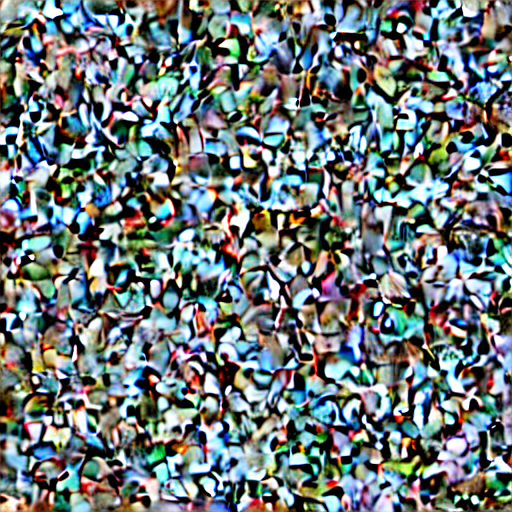

In [57]:
# creating a PIL image
Image.fromarray(scaled[0])

In [58]:
# creating a function that returns the image corresponding to a latent vector
def latents_to_image(latents, vae=vae):
    """Transform the latent vector to a image, using a VAE decoder.

    Inputs:  latents  Latent vector(s) as a 4-D PyTorch tensor.  Only
                      the first element of the batch will be used.
             vae      The VAE used to decode the image from latents.

    Outputs: A PIL image corresponding to the latents.
    """
    # Scaling factor
    scaling_factor = torch.tensor(vae.config.scaling_factor, device=device, dtype=dtype)
    
    # Decode the latents
    
    with torch.no_grad():
        decoded = vae.decode(latents / scaling_factor).sample
    # Permute the dimensions and convert to NumPy
    unscaled = decoded.permute(0, 2, 3, 1).cpu().numpy()
    # Scale the image values to be between 0 and 255
    scaled = ((unscaled + 1) * 255 / 2).clip(0, 255).round().astype("uint8")
    # Return a PIL image
    return Image.fromarray(scaled[0])

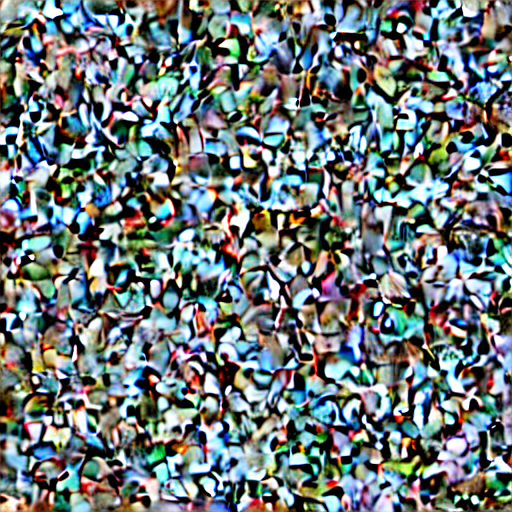

In [59]:
latents_to_image(random_latents)

### Denoising Diffusion

In [60]:
import diffusers
import torch
# to denoise this image generated from random vectors
# we need a model to predict the noise in the random vectors

unet = diffusers.UNet2DConditionModel.from_pretrained(
    'CompVis/stable-diffusion-v1-4', 
    subfolder = 'unet',
    torch_dtype = torch.float16,
    local_files_only = True
)

In [61]:
unet.to(device)

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

In [62]:
summary(unet)

Layer (type:depth-idx)                                            Param #
UNet2DConditionModel                                              --
├─Conv2d: 1-1                                                     11,840
├─Timesteps: 1-2                                                  --
├─TimestepEmbedding: 1-3                                          --
│    └─Linear: 2-1                                                410,880
│    └─SiLU: 2-2                                                  --
│    └─Linear: 2-3                                                1,639,680
├─ModuleList: 1-4                                                 --
│    └─CrossAttnDownBlock2D: 2-4                                  --
│    │    └─ModuleList: 3-1                                       5,092,480
│    │    └─ModuleList: 3-2                                       4,510,080
│    │    └─ModuleList: 3-3                                       921,920
│    └─CrossAttnDownBlock2D: 2-5                               

##### Using the scheduler

In [63]:
# the scheduler is used to run the process in a number of small steps
scheduler = diffusers.UniPCMultistepScheduler.from_pretrained(
    'CompVis/stable-diffusion-v1-4',
    subfolder = 'scheduler',
    local_files_only = True
)

In [64]:
print(scheduler)

UniPCMultistepScheduler {
  "_class_name": "UniPCMultistepScheduler",
  "_diffusers_version": "0.36.0",
  "beta_end": 0.012,
  "beta_schedule": "scaled_linear",
  "beta_start": 0.00085,
  "clip_sample": false,
  "disable_corrector": [],
  "dynamic_thresholding_ratio": 0.995,
  "final_sigmas_type": "zero",
  "flow_shift": 1.0,
  "lower_order_final": true,
  "num_train_timesteps": 1000,
  "predict_x0": true,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "set_alpha_to_one": false,
  "skip_prk_steps": true,
  "solver_order": 2,
  "solver_p": null,
  "solver_type": "bh2",
  "steps_offset": 1,
  "thresholding": false,
  "time_shift_type": "exponential",
  "timestep_spacing": "linspace",
  "trained_betas": null,
  "use_beta_sigmas": false,
  "use_dynamic_shifting": false,
  "use_exponential_sigmas": false,
  "use_flow_sigmas": false,
  "use_karras_sigmas": false
}



In [65]:
# creating a starting latent vector by multiplying our random latent
# by the schedulers 'init_noise_sigma'
random_latents.shape

torch.Size([1, 4, 64, 64])

In [66]:
## it's one but we'll still use it( other schedulers might not be one)
scheduler.init_noise_sigma

1.0

In [67]:
latents = random_latents * scheduler.init_noise_sigma

In [68]:
latents.shape

torch.Size([1, 4, 64, 64])

### Denoising the latents****

In [69]:
# just a single step

scheduler.set_timesteps(1)
print('Steps:', scheduler.timesteps)

Steps: tensor([999])


In [70]:
# value of the first time steps
t = scheduler.timesteps[0]
print(t)

tensor(999)


In [71]:
# we need to run the denoising model with the conditionaed and the unconditioned inputs
latent_inputs = torch.cat(
    [latents, latents]
)

In [72]:
print(latent_inputs.shape)

torch.Size([2, 4, 64, 64])


In [73]:
# predicting noise for unconditioned embeddings and conditioned embeddingd which are in all_embeddings
scaled_inputs = scheduler.scale_model_input(latent_inputs, timestep = t)
with torch.no_grad():
    noise = unet(scaled_inputs, t, encoder_hidden_states=all_embeddings)

In [74]:
# split the predictions
noise_uncond, noise_cond = noise.sample.chunk(2)

In [75]:
print(noise_uncond)


tensor([[[[ 1.4912,  0.4343, -0.4106,  ..., -0.7139,  1.6582, -1.6201],
          [-0.7910, -0.4314,  0.7871,  ..., -0.3616, -0.5610,  0.4172],
          [ 0.3364, -0.2727, -0.2920,  ...,  0.5967,  0.0174,  0.8042],
          ...,
          [ 1.3037, -1.0537, -0.4927,  ..., -1.1709,  0.5918, -1.5986],
          [-0.3276,  0.6089,  1.5732,  ..., -0.4434,  0.1985, -0.7329],
          [ 0.9189,  0.6992, -0.4253,  ...,  1.0410, -1.5703,  0.8521]],

         [[ 1.6875,  0.7129, -0.4883,  ..., -0.5732, -0.2407,  0.0129],
          [ 1.1133, -0.6890,  1.2578,  ..., -0.5635,  0.8052,  0.3132],
          [ 1.5566, -0.0578, -1.0693,  ...,  0.3118,  1.0713, -0.9116],
          ...,
          [-0.5220, -0.1357,  0.7236,  ..., -1.4443,  0.3997,  1.6602],
          [ 0.8628,  0.1917,  1.0635,  ..., -0.5039,  1.3789,  1.9746],
          [ 1.3486,  1.6680,  0.7358,  ...,  0.3003, -0.7788, -0.7393]],

         [[-2.4785,  0.4043,  0.2715,  ...,  0.0799, -0.2886, -0.5283],
          [ 0.7603,  1.1641, -

In [76]:
guidance_scale = 12    # tells us how strictly we should follow the prompt
noise_pred = noise_uncond + guidance_scale * (noise_cond - noise_uncond)

In [77]:
print(noise_pred.shape)

torch.Size([1, 4, 64, 64])


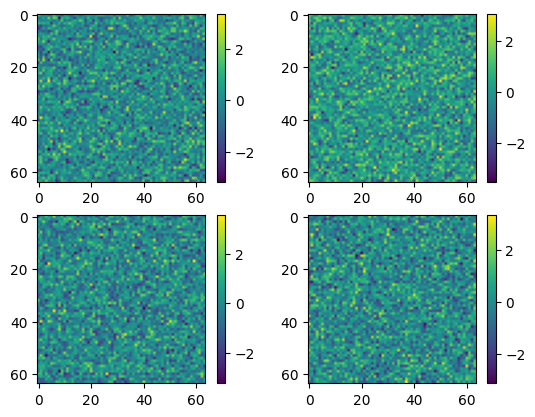

In [78]:
# plotting the predicted noise
plot_latents(noise_pred)

In [79]:
# removing the predicted noise from the latent vector
latents = scheduler.step(noise_pred, t, latents).prev_sample

In [80]:
latents.shape

torch.Size([1, 4, 64, 64])

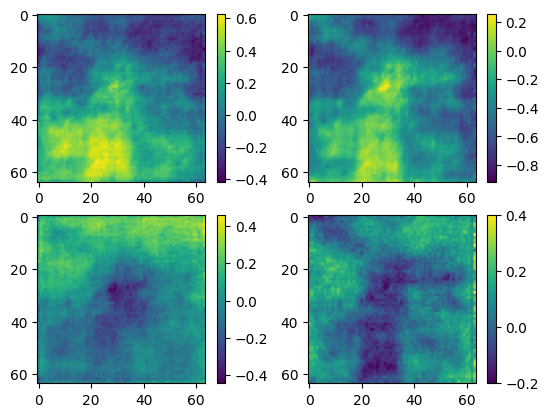

In [81]:
plot_latents(latents)

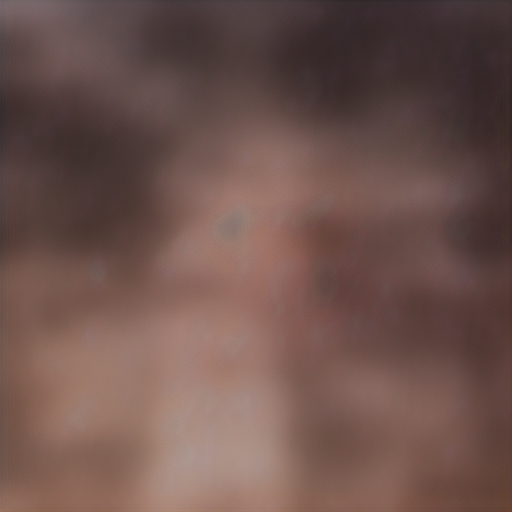

In [82]:
# convert the latents to image
latents_to_image(latents)

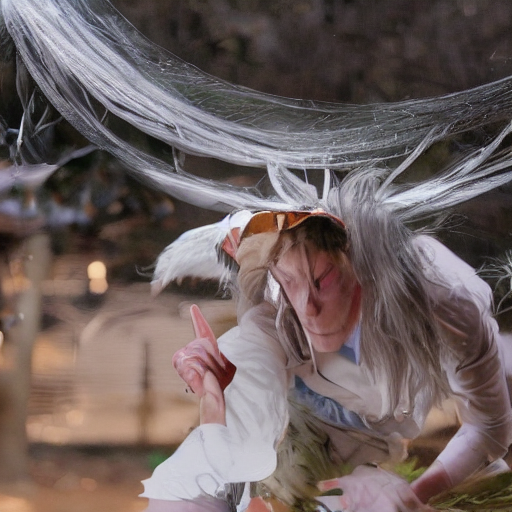

In [83]:
# loop to run the denoising steps for more steps
num_steps = 120
scheduler.set_timesteps(num_steps)
latents = random_latents * scheduler.init_noise_sigma
display_handle = display(latents_to_image(latents, vae), display_id='latent_display')

In [84]:
# loop to run the denoising steps for more steps
with torch.no_grad():
    for t in tqdm(scheduler.timesteps):
        latent_inputs = torch.cat([
            latents, latents
        ])
        latent_inputs = scheduler.scale_model_input(latent_inputs, t)
        noise = unet(latent_inputs, t, encoder_hidden_states= all_embeddings)
        noise_uncond, noise_cond = noise.sample.chunk(2)
        guidance_scale = 13
        noise_pred = noise_uncond + guidance_scale * (noise_cond - noise_uncond)
        latents = scheduler.step(noise_pred, t, latents).prev_sample
        display_handle.update(latents_to_image(latents, vae))

  0%|          | 0/120 [00:00<?, ?it/s]

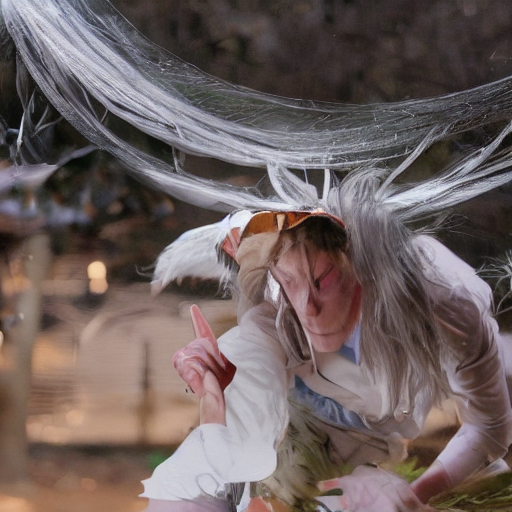

In [85]:
from PIL import Image
import numpy as np

# Decode latent -> image
with torch.no_grad():
    image = vae.decode(
        latents / vae.config.scaling_factor
    ).sample

# Convert from [-1,1] -> [0,1]
image = (image / 2 + 0.5).clamp(0, 1)

# Convert tensor format
image = image.cpu().permute(0, 2, 3, 1).float().numpy()

# Convert to uint8
image = (image[0] * 255).astype(np.uint8)

# PIL image
final_image = Image.fromarray(image)

# Display
display(final_image)

well the image is not so good

This process can just be automated using stable diffusion pipelines and save the stress and errors
pipeline = diffusers.StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4", torch_dtype=dtype,
    local_files_only=True
)
res = pipeline(prompt)

you can even set the guidance_scale and the number of steps(num_inference)